In [33]:
import re
import glob
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None

In [34]:
model_name = lambda name: ' '.join(re.findall(r'([a-z]+)', name)[:2]).capitalize()
compute_duration = lambda x: x.max() - x.min()
def read_csv(paths: list, dropna=True) -> pd.DataFrame:
  df = pd.concat([ pd.read_csv(path) for path in paths])
  if dropna:
    df.dropna(inplace=True)
  return df
columns = [
  'metrics-daemon/cuda:0 (gpu:0)/gpu_utilization (%)/mean',
  'metrics-daemon/cuda:1 (gpu:1)/gpu_utilization (%)/mean',
  'metrics-daemon/cuda:2 (gpu:2)/gpu_utilization (%)/mean',
  'metrics-daemon/cuda:3 (gpu:3)/gpu_utilization (%)/mean',
  ]
Approach = dict(infaas="INFaaS", usher="Usher", roomie_heuristic_v2="Roomie")

In [35]:
WORKDIR = "JetsonNano/synthetic_running4x"
WORKDIR = "NvidiaA100/synthetic_running4x"

In [36]:
# for subdir in sorted(glob.glob(f"{WORKDIR}/*")):
#   qps = int(re.findall(r"qps(\d+)", subdir).pop())
#   print(f"| Query per second: {qps} |")
#   for approach in Approach:
#     paths = glob.glob(f"{subdir}/{approach}/controller.csv")
#     if not paths: continue
#     df = read_csv(paths=paths)
#     throughput = len(df) / (df["in_sys_timestamp"].max() - df["in_sys_timestamp"].min())
#     err = abs(throughput - qps) / throughput * 100
#     if err < 5:
#       throughput = qps
#     print(f"- {Approach[approach]}:\t{throughput:.0f}")

In [ ]:
data = []
for subdir in sorted(glob.glob(f"{WORKDIR}/*")):
  qps = int(re.findall(r"qps(\d+)", subdir).pop())
  for approach in Approach:
    paths = glob.glob(f"{subdir}/{approach}/controller.csv")
    if paths:
      # Throughput (queries send per second)
      df = read_csv(paths=paths)
      throughput = len(df) / (df["in_sys_timestamp"].max() - df["in_sys_timestamp"].min())
      err = abs(throughput - qps) / throughput * 100
      if err < 5:
        throughput = qps
      # Goodput (queries processed per second)
      df = read_csv(paths=glob.glob(f"{subdir}/{approach}/*/worker*.csv"))
      goodput = df["batch_size"].sum() / (df["timestamp"].max() - df["timestamp"].min())
      # Aggregated goodput (goodput per model)
      # for approach in Approach:
      #   df_worker = pd.concat([pd.read_csv(path) for path in glob.glob(f"{directory}/{approach}/*/worker*.csv")])
      #   df_controller = pd.concat([pd.read_csv(path) for path in glob.glob(f"{directory}/{approach}/controller.csv")]).rename(columns={"app_id": "name"})
      #   max_duration = df_controller["at"].max()
      #   df_worker = df_worker[df_worker["at"] <= max_duration]
      #   df_worker = df_worker.groupby("name")["batch_size"].sum().reset_index().rename(columns={"batch_size": "goodput"})
      #   df_controller = df_controller["name"].value_counts().reset_index().rename(columns={"count": "throughput"})
      #   df = pd.merge(df_controller, df_worker, on="name")
      #   normalized_goodput = (df["goodput"] / df["throughput"]).mean()
      #   print(f"{approach}: {normalized_goodput:.2f}")
      
      # Response time
      avg_response_time = ((df["timestamp"] - df["in_sys_timestamp"]) / df["batch_size"]).mean()
      
      # GPU utilization (%)
      df = read_csv(paths=glob.glob(f"{subdir}/{approach}/*/*gpu_trace.csv"), dropna=False)
      try:
        df["timestamp"] = df["time"].apply(lambda x: int(pd.to_datetime(x).timestamp()))
        df.rename(columns={ "GPU": "gpu_utilization" }, inplace=True)
      except:
        df.rename(columns={ "metrics-daemon/timestamp": "timestamp" }, inplace=True)
        df["gpu_utilization"] = df[columns].mean(axis=1)
      start, end = df["timestamp"].min(), df["timestamp"].max()
      duration = end - start
      df = df[(df["timestamp"] >= (start + duration * .5)) & (df["timestamp"] <= (end - duration * .2))]
      avg_utilization = df["gpu_utilization"].mean()
    else:
      throughput = qps
      goodput = None
      avg_response_time = None
      avg_utilization = None
    data += [{
      "qps": qps,
      "approach": Approach[approach],
      "throughput": throughput,
      "goodput": goodput,
      "avg_response_time": avg_response_time,
      "avg_utilization": avg_utilization,
      }]
data = pd.DataFrame(data)
data.head()

# Goodput

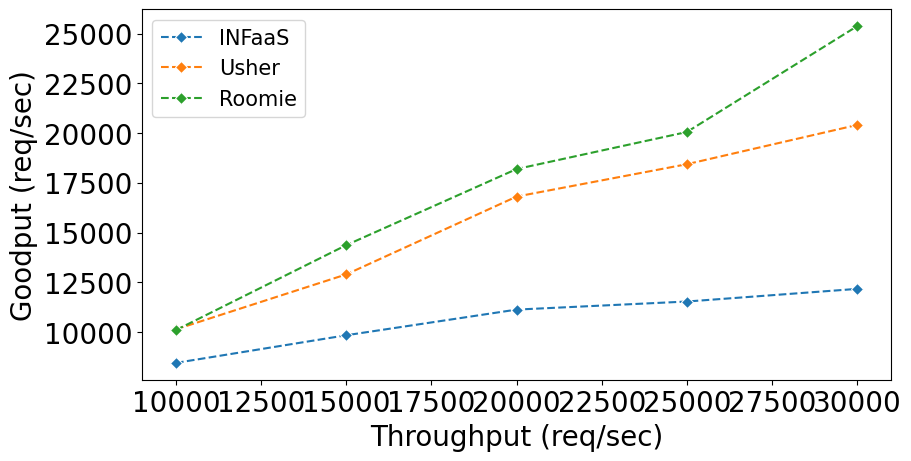

In [ ]:
plt.figure(figsize=(9, 4.5), layout="constrained")
sns.lineplot(data, x="throughput", y="goodput", hue="approach", marker="D", linestyle="--")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Throughput (req/sec)", fontsize=20)
plt.ylabel("Goodput (req/sec)", fontsize=20)
plt.legend(fontsize=15)
plt.show()

# Response-Time

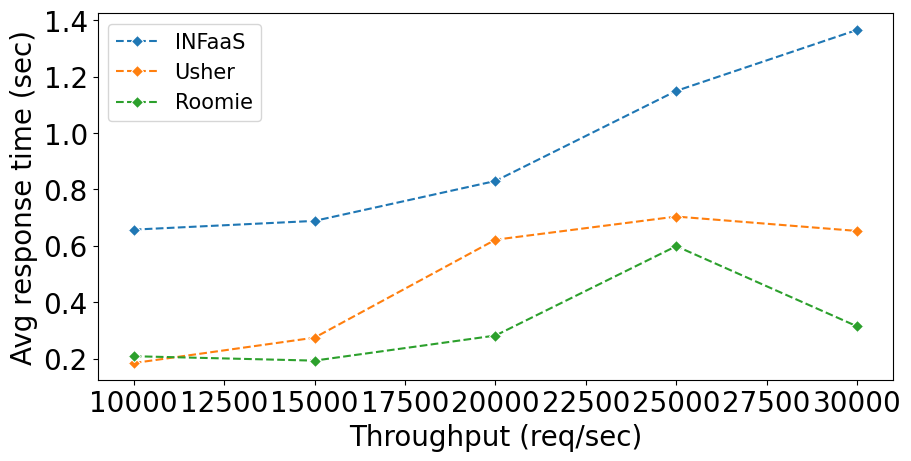

In [ ]:
plt.figure(figsize=(9, 4.5), layout="constrained")
sns.lineplot(data, x="throughput", y="avg_response_time", hue="approach", marker="D", linestyle="--")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Throughput (req/sec)", fontsize=20)
plt.ylabel("Avg response time (sec)", fontsize=20)
plt.legend(fontsize=15)
plt.show()

In [ ]:
# columns = [
#   'metrics-daemon/cuda:0 (gpu:0)/gpu_utilization (%)/mean',
#   'metrics-daemon/cuda:1 (gpu:1)/gpu_utilization (%)/mean',
#   'metrics-daemon/cuda:2 (gpu:2)/gpu_utilization (%)/mean',
#   'metrics-daemon/cuda:3 (gpu:3)/gpu_utilization (%)/mean',
#   ]

# gpu_utilization_data = []
# for subdir in sorted(glob.glob(f"{WORKDIR}/*")):
#   qps = int(re.findall(r"qps(\d+)", subdir).pop())
#   for approach in Approach:
#     paths = glob.glob(f"{subdir}/{approach}/controller.csv")
#     if paths:
#       # Throughput (queries send per second)
#       df = read_csv(paths=paths)
#       throughput = len(df) / (df["timestamp"].max() - df["timestamp"].min())
#       err = abs(throughput - qps) / throughput * 100
#       if err < 5:
#         throughput = qps
#       # GPU utilization (%)
#       df = read_csv(paths=glob.glob(f"{subdir}/{approach}/*/*gpu_trace.csv"), dropna=False)
#       try:
#         df["timestamp"] = df["time"].apply(lambda x: int(pd.to_datetime(x).timestamp()))
#         df.rename(columns={ "GPU": "gpu_utilization" }, inplace=True)
#       except:
#         df.rename(columns={ "metrics-daemon/timestamp": "timestamp" }, inplace=True)
#         df["gpu_utilization"] = df[columns].mean(axis=1)
#       start, end = df["timestamp"].min(), df["timestamp"].max()
#       duration = end - start
#       df = df[(df["timestamp"] >= (start + duration * .5)) & (df["timestamp"] <= (end - duration * .2))]
#       avg_utilization = df["gpu_utilization"].mean()
#     else:
#       throughput = qps
#       avg_utilization = None
#     gpu_utilization_data += [{
#       "qps": qps,
#       "approach": Approach[approach],
#       "throughput": throughput,
#       "avg_utilization": avg_utilization,
#     }]
# gpu_utilization_data = pd.DataFrame(gpu_utilization_data)
# gpu_utilization_data.head()    

,qps,approach,throughput,avg_utilization
0,10000,INFaaS,10000,NaN
1,10000,Usher,10000,NaN
2,10000,Roomie,10000,NaN
3,15000,INFaaS,15000,NaN
4,15000,Usher,15000,NaN


# GPU Utilization

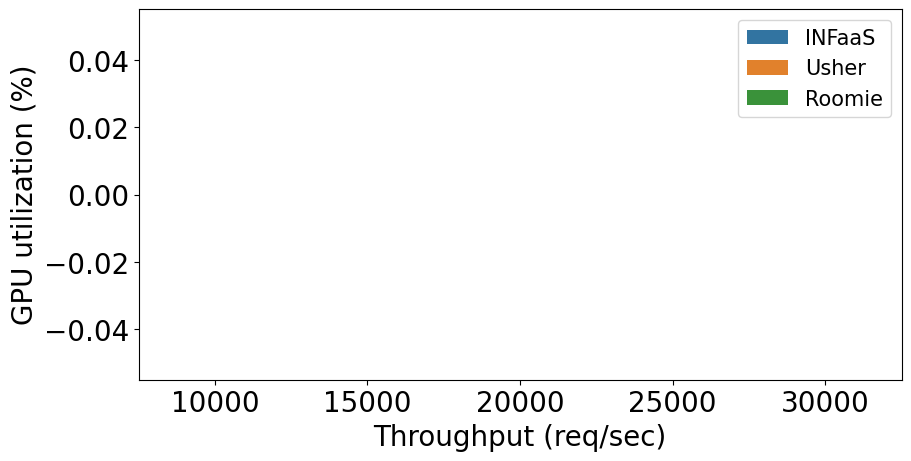

In [ ]:
plt.figure(figsize=(9, 4.5), layout="constrained")
sns.barplot(gpu_utilization_data, x="throughput", y="avg_utilization", hue="approach")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Throughput (req/sec)", fontsize=20)
plt.ylabel("GPU utilization (%)", fontsize=20)
plt.legend(fontsize=15)
plt.show()